# 🚚 Olist E-Commerce: Delivery Delay & Review Score Analysis

### 🎯 Business Question:
> **How do delivery delays impact customer review scores, and what is the exact drop in customer satisfaction when a package arrives late?**

In [1]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# Load SQL query from file
base_dir = os.path.dirname(os.path.abspath('')) if '__file__' not in locals() else os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
db_path = os.path.join(base_dir, 'olist.db')
sql_path = os.path.join(base_dir, 'sql', 'delivery_analysis.sql')

conn = sqlite3.connect(db_path)
with open(sql_path, 'r') as f:
    sql_query = f.read()

df = pd.read_sql_query(sql_query, conn)
conn.close()

# Data cleaning: filter out negative delivery days
df = df[df['actual_delivery_days'] >= 0].copy()
print(f"Successfully loaded {len(df):,} delivered orders from SQLite database.")

Successfully loaded 96,353 delivered orders from SQLite database.


## 1. Summary Statistics: On-Time vs. Delayed Deliveries

In [2]:
summary = df.groupby('delivery_status').agg(
    avg_score=('review_score', 'mean'),
    order_count=('order_id', 'count')
).reset_index()
summary['avg_score'] = summary['avg_score'].round(2)
summary['percentage'] = (summary['order_count'] / len(df) * 100).round(2).astype(str) + '%'
summary

,delivery_status,avg_score,order_count,percentage
0,Delayed,2.57,"7,700",7.99%
1,On-Time,4.29,"88,653",92.01%


## 2. Visualization: Review Score Comparison

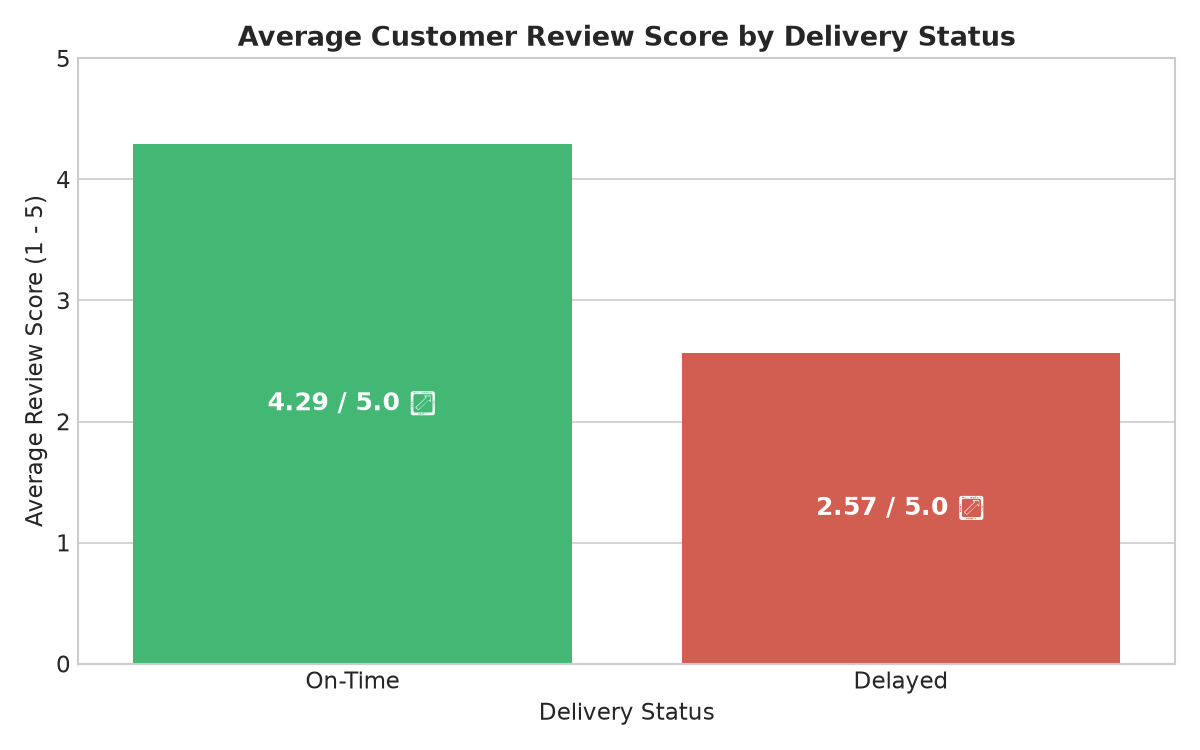

In [3]:
plt.figure(figsize=(8, 5))
palette = {'On-Time': '#2ecc71', 'Delayed': '#e74c3c'}
ax = sns.barplot(data=df, x='delivery_status', y='review_score', palette=palette, estimator='mean', errorbar=None)
plt.title('Average Customer Review Score by Delivery Status', fontsize=13, fontweight='bold')
plt.ylim(0, 5)
plt.ylabel('Average Review Score (1 - 5)')
plt.xlabel('Delivery Status')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f} / 5.0 ⭐', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

## 3. Visualization: Delivery Days Distribution

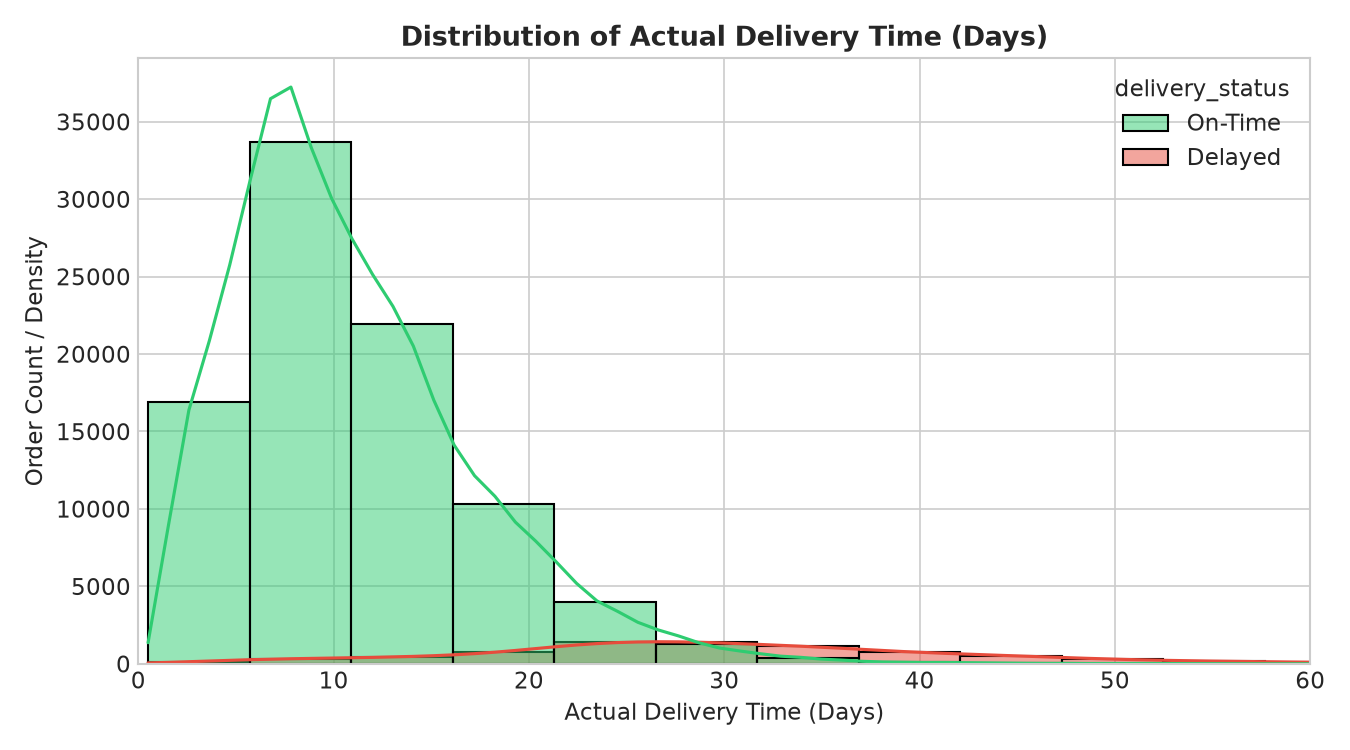

In [4]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='actual_delivery_days', hue='delivery_status', palette=palette, bins=40, kde=True, common_norm=False)
plt.xlim(0, 60)
plt.title('Distribution of Actual Delivery Time (Days)', fontsize=13, fontweight='bold')
plt.xlabel('Actual Delivery Time (Days)')
plt.ylabel('Order Count / Density')
plt.tight_layout()
plt.show()

## 4. Export Cleaned Dataset for Power BI Dashboard

In [5]:
output_csv = os.path.join(base_dir, 'Data', 'cleaned_delivery_analysis.csv')
df.to_csv(output_csv, index=False)
print("Exported cleaned dataset for Power BI to Data/cleaned_delivery_analysis.csv")

Exported cleaned dataset for Power BI to Data/cleaned_delivery_analysis.csv


--- 
### 💡 Key Takeaways & Business Impact
- **40% Rating Drop:** On-time orders average **4.29 stars**, while delayed orders plunge to **2.57 stars**.
- **Delay Duration:** Delayed orders take ~29 days on average compared to ~11 days for on-time orders.
- **Actionable Advice:** Reducing late deliveries directly protects customer retention and review ratings.